In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pwd

/content


In [3]:
%cd '/content/drive/MyDrive/Projects/Water quality'

/content/drive/MyDrive/Projects/Water quality


In [4]:
!pwd

/content/drive/MyDrive/Projects/Water quality


### Downloading data from Kaggle

In [5]:
!pip install --upgrade kaggle

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.2/126.2 kB 4.2 MB/s eta 0:00:00
  Attempting uninstall: kaggle
    Found existing installation: kaggle 2.0.2
    Uninstalling kaggle-2.0.2:
      Successfully uninstalled kaggle-2.0.2


In [6]:
!kaggle datasets download mobinaroudgar/water-quality

Dataset URL: https://www.kaggle.com/datasets/mobinaroudgar/water-quality
License(s): other
water-quality.zip: Skipping, found more recently modified local copy (use --force to force download)


In [7]:
!ls

 Data.ipynb		 water_potability.csv	 WaterQualityModel_retry.bin
'Training logs.gsheet'	 WaterQualityModel.bin	 water-quality.zip


#### Unzipping zip file

In [8]:
from zipfile import ZipFile

with ZipFile('water-quality.zip', 'r') as f:
  print('Unzipping file...')
  f.extractall()
  print('Done!')

Unzipping file...
Done!


In [9]:
!ls

 Data.ipynb		 water_potability.csv	 WaterQualityModel_retry.bin
'Training logs.gsheet'	 WaterQualityModel.bin	 water-quality.zip


In [10]:
!ls

 Data.ipynb		 water_potability.csv	 WaterQualityModel_retry.bin
'Training logs.gsheet'	 WaterQualityModel.bin	 water-quality.zip


## Data cleaning and splitting

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
df_raw = pd.read_csv('water_potability.csv')

In [13]:
df_raw

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0
...,...,...,...,...,...,...,...,...,...,...
3271,4.668102,193.681735,47580.991603,7.166639,359.948574,526.424171,13.894419,66.687695,4.435821,1
3272,7.808856,193.553212,17329.802160,8.061362,NaN,392.449580,19.903225,NaN,2.798243,1
3273,9.419510,175.762646,33155.578218,7.350233,NaN,432.044783,11.039070,69.845400,3.298875,1
3274,5.126763,230.603758,11983.869376,6.303357,NaN,402.883113,11.168946,77.488213,4.708658,1


## EDA

In [14]:
df_raw.describe()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
count,2785.000000,3276.000000,3276.000000,3276.000000,2495.000000,3276.000000,3276.000000,3114.000000,3276.000000,3276.000000
mean,7.080795,196.369496,22014.092526,7.122277,333.775777,426.205111,14.284970,66.396293,3.966786,0.390110
std,1.594320,32.879761,8768.570828,1.583085,41.416840,80.824064,3.308162,16.175008,0.780382,0.487849
min,0.000000,47.432000,320.942611,0.352000,129.000000,181.483754,2.200000,0.738000,1.450000,0.000000
25%,6.093092,176.850538,15666.690297,6.127421,307.699498,365.734414,12.065801,55.844536,3.439711,0.000000
50%,7.036752,196.967627,20927.833607,7.130299,333.073546,421.884968,14.218338,66.622485,3.955028,0.000000
75%,8.062066,216.667456,27332.762127,8.114887,359.950170,481.792304,16.557652,77.337473,4.500320,1.000000
max,14.000000,323.124000,61227.196008,13.127000,481.030642,753.342620,28.300000,124.000000,6.739000,1.000000


In [15]:
df_raw.columns

Index(['ph', 'Hardness', 'Solids', 'Chloramines', 'Sulfate', 'Conductivity',
       'Organic_carbon', 'Trihalomethanes', 'Turbidity', 'Potability'],
      dtype='object')

In [16]:
df_raw.dtypes

,0
ph,float64
Hardness,float64
Solids,float64
Chloramines,float64
Sulfate,float64
Conductivity,float64
Organic_carbon,float64
Trihalomethanes,float64
Turbidity,float64
Potability,int64


All features are numerical values

In [17]:
target_feat = 'Potability'

In [18]:
df_raw.isnull().sum()

,0
ph,491
Hardness,0
Solids,0
Chloramines,0
Sulfate,781
Conductivity,0
Organic_carbon,0
Trihalomethanes,162
Turbidity,0
Potability,0


In [19]:
(df_raw.isnull().sum() / len(df_raw)) * 100

,0
ph,14.987790
Hardness,0.000000
Solids,0.000000
Chloramines,0.000000
Sulfate,23.840049
Conductivity,0.000000
Organic_carbon,0.000000
Trihalomethanes,4.945055
Turbidity,0.000000
Potability,0.000000


Sulfate has a lot of null values (23% of the column)

Checking correlation matrix of the features

In [20]:
corr = df_raw.corr()

<Axes: >

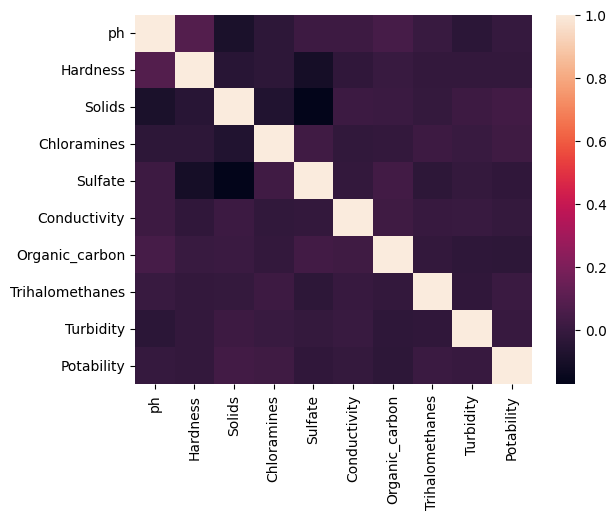

In [21]:
sns.heatmap(corr)

No obvious correlation between the features, especially wrt Potability

Checking distribution of the different features

Feature: ph


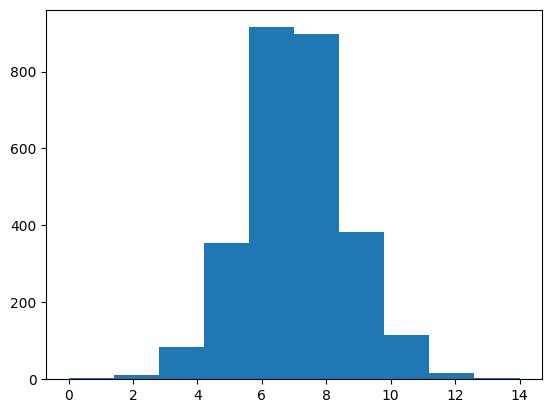


Feature: Hardness


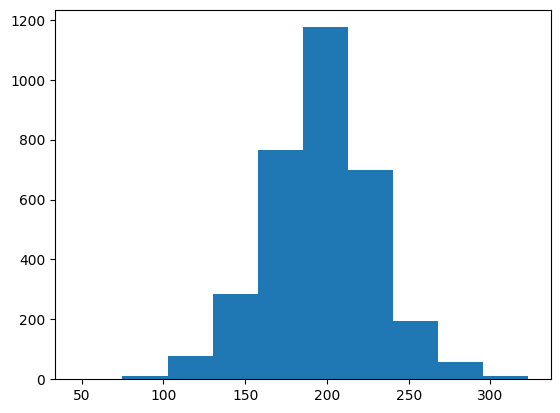


Feature: Solids


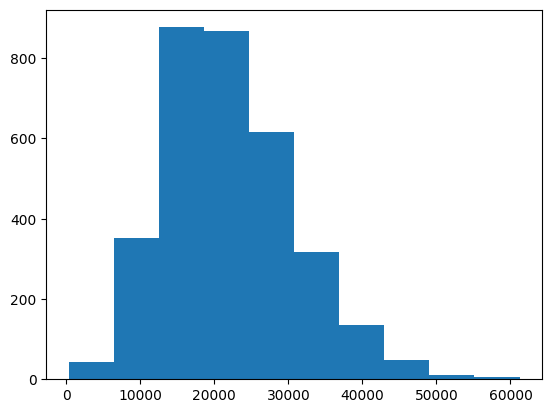


Feature: Chloramines


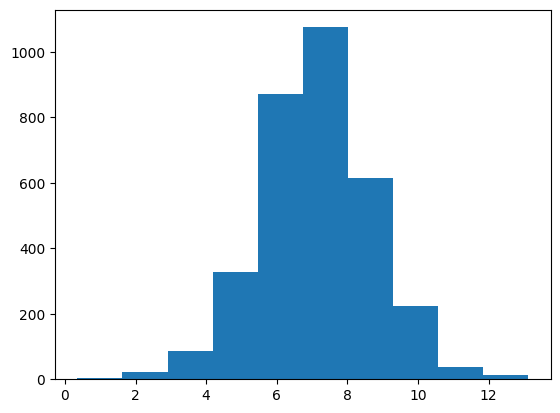


Feature: Sulfate


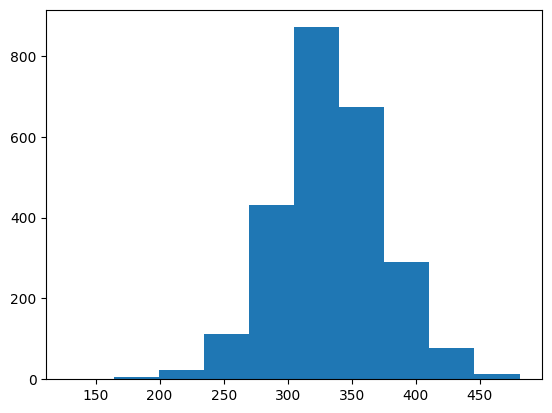


Feature: Conductivity


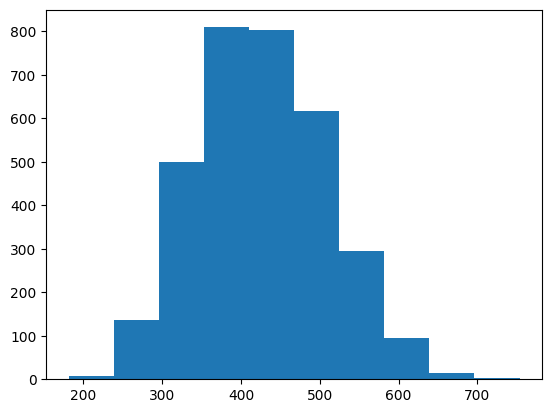


Feature: Organic_carbon


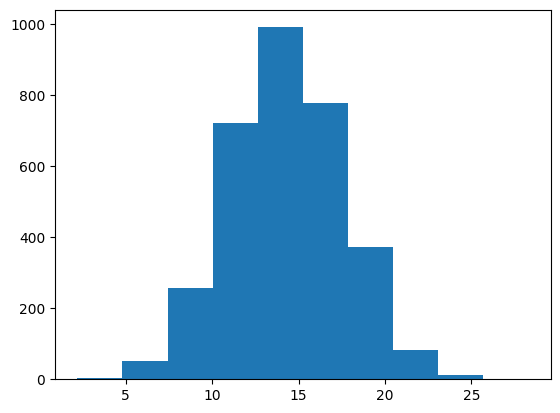


Feature: Trihalomethanes


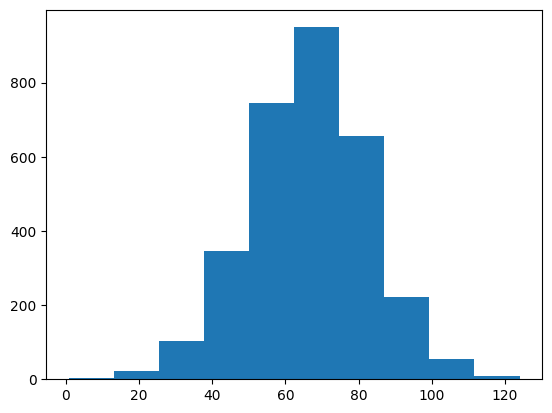


Feature: Turbidity


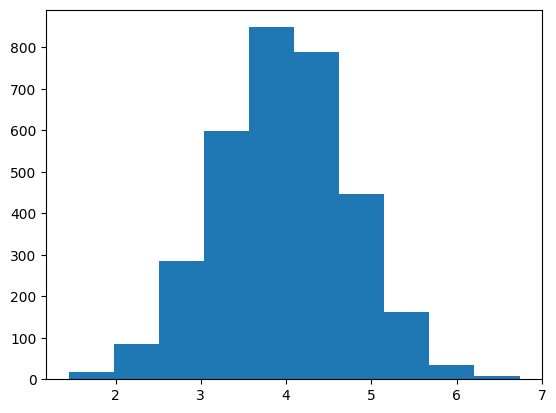

In [22]:
for col in df_raw.columns:
  if col == target_feat:
    continue
  print(f'Feature: {col}')
  plt.hist(df_raw[col])
  plt.show()
  print()

target feature distribution

<Axes: xlabel='Potability'>

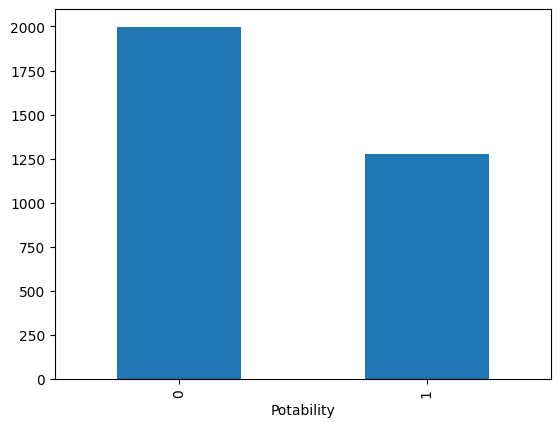

In [26]:
df_raw[target_feat].value_counts().plot(kind='bar')

In [27]:
df_raw[target_feat].value_counts() / len(df_raw)

,count
Potability,
0,0.60989
1,0.39011


checking null values

In [28]:
for col in df_raw.columns:
  if col == target_feat:
    continue
  if df_raw[col].isna().sum().item() > 0:
    print(f'Comparing proportion of values of Potability for feature "{col}"')
    print("Null:")
    print(df_raw[df_raw[col].isna()]['Potability'].value_counts()/df_raw[df_raw[col].isna()]['Potability'].value_counts().sum())
    print("Non null:")
    print(df_raw[df_raw[col].isna() == False]['Potability'].value_counts()/df_raw[df_raw[col].isna() == False]['Potability'].value_counts().sum())
    print()

Comparing proportion of values of Potability for feature "ph"
Null:
Potability
0    0.639511
1    0.360489
Name: count, dtype: float64
Non null:
Potability
0    0.604668
1    0.395332
Name: count, dtype: float64

Comparing proportion of values of Potability for feature "Sulfate"
Null:
Potability
0    0.62484
1    0.37516
Name: count, dtype: float64
Non null:
Potability
0    0.60521
1    0.39479
Name: count, dtype: float64

Comparing proportion of values of Potability for feature "Trihalomethanes"
Null:
Potability
0    0.660494
1    0.339506
Name: count, dtype: float64
Non null:
Potability
0    0.607258
1    0.392742
Name: count, dtype: float64



Mostly the proportion of 0 and 1 in the null features are similar. Trihalomethanes has the highest different, but it only has 4% of it's values as null

## Train validation test split

In [45]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df_raw.drop(target_feat, axis='columns'), df_raw[target_feat], test_size=0.2, random_state=2)
X_test, X_val, y_test, y_val = train_test_split(X_test, y_test, test_size=0.5, random_state=42)

In [46]:
y_train

,Potability
3216,1
3050,0
739,1
2100,0
2035,1
...,...
2347,1
1608,1
2541,0
2575,0


In [47]:
X_train

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity
3216,5.609235,216.122673,14825.934502,7.001788,355.211678,330.092674,9.779518,41.249977,3.224676
3050,8.479593,200.765679,14901.808144,7.379506,NaN,485.093167,16.806347,53.134170,4.221266
739,6.772157,196.900098,13790.296202,9.575053,NaN,347.588375,17.705727,68.379815,3.827256
2100,4.894278,184.552715,10922.541994,7.461703,352.830222,338.681069,21.624718,91.007934,3.594991
2035,5.763773,183.073629,22025.696606,8.952896,NaN,376.581389,10.547398,63.299757,3.253200
...,...,...,...,...,...,...,...,...,...
2347,5.429335,183.439383,15265.407564,5.714731,394.001195,446.879149,17.581557,50.266951,3.081736
1608,6.919726,194.859000,35558.731647,6.371978,299.786711,394.829326,11.983961,69.853135,4.120828
2541,5.735724,158.318741,25363.016594,7.728601,377.543291,568.304671,13.626624,75.952337,4.732954
2575,6.914868,206.249937,10343.378848,7.771206,324.383170,521.320673,16.173730,68.246945,2.988611


In [48]:
X_test

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity
2013,NaN,192.742275,32349.102378,8.750630,272.085057,581.981191,13.583036,64.436046,3.952594
861,NaN,184.750698,28499.107328,6.550031,330.719549,381.501604,11.044405,62.014822,3.403270
599,NaN,205.638790,39742.970329,4.660528,323.956492,509.546419,11.674850,55.042679,3.916746
1975,6.804796,223.995701,17196.054711,7.112622,374.309131,344.718314,15.457383,60.151346,4.847313
20,NaN,227.435048,22305.567414,10.333918,NaN,554.820086,16.331693,45.382815,4.133423
...,...,...,...,...,...,...,...,...,...
3217,NaN,98.367915,28415.575832,10.558950,296.843208,505.240269,12.882614,85.329955,4.119087
3078,11.390543,145.341937,16175.221944,6.613865,NaN,553.488923,12.091189,69.736231,2.277359
1561,6.227827,169.926222,22550.492264,4.973593,297.404497,460.415386,20.789592,93.300733,4.007347
699,7.376449,168.750007,37191.114141,4.184943,NaN,439.312853,15.900985,63.334895,5.767355


In [49]:
y_train.value_counts()/len(y_train)

,count
Potability,
0,0.604962
1,0.395038


In [50]:
y_test.value_counts()/len(y_test)

,count
Potability,
0,0.655488
1,0.344512


In [51]:
y_val.value_counts()/len(y_val)

,count
Potability,
0,0.603659
1,0.396341


Imputing null values with mean

In [52]:
for col in X_train.columns:
  X_train[col] = X_train[col].fillna(X_train[col].mean())
  X_val[col] = X_val[col].fillna(X_val[col].mean())
  X_test[col] = X_test[col].fillna(X_test[col].mean())

In [53]:
df_raw.isnull().sum()

,0
ph,491
Hardness,0
Solids,0
Chloramines,0
Sulfate,781
Conductivity,0
Organic_carbon,0
Trihalomethanes,162
Turbidity,0
Potability,0


In [54]:
X_train.isnull().sum()

,0
ph,0
Hardness,0
Solids,0
Chloramines,0
Sulfate,0
Conductivity,0
Organic_carbon,0
Trihalomethanes,0
Turbidity,0


In [55]:
X_val.isnull().sum()

,0
ph,0
Hardness,0
Solids,0
Chloramines,0
Sulfate,0
Conductivity,0
Organic_carbon,0
Trihalomethanes,0
Turbidity,0


In [56]:
X_test.isnull().sum()

,0
ph,0
Hardness,0
Solids,0
Chloramines,0
Sulfate,0
Conductivity,0
Organic_carbon,0
Trihalomethanes,0
Turbidity,0


converting data to tensors

In [57]:
import torch
from torch import nn
from torch import optim as op

In [58]:
X_train_tensor = torch.from_numpy(X_train.to_numpy()).type(torch.float)
y_train_tensor = torch.from_numpy(y_train.to_numpy()).type(torch.float)

X_val_tensor = torch.from_numpy(X_val.to_numpy()).type(torch.float)
y_val_tensor = torch.from_numpy(y_val.to_numpy()).type(torch.float)

X_test_tensor = torch.from_numpy(X_test.to_numpy()).type(torch.float)
y_test_tensor = torch.from_numpy(y_test.to_numpy()).type(torch.float)

Min max Scaling

In [59]:
x_min, x_max = torch.min(X_train_tensor, dim=0, keepdim=True)[0], torch.max(X_train_tensor, dim=0, keepdim=True)[0]

In [60]:
x_min, x_max

(tensor([[  0.0000,  73.4922, 320.9426,   0.3520, 129.0000, 181.4837,   2.2000,
            0.7380,   1.4500]]),
 tensor([[1.4000e+01, 3.1734e+02, 6.1227e+04, 1.3127e+01, 4.7654e+02, 7.0823e+02,
          2.7007e+01, 1.2400e+02, 6.7390e+00]]))

In [61]:
X_train_tensor = (X_train_tensor - x_min) / (x_max - x_min)

In [62]:
X_train_tensor

tensor([[0.4007, 0.5849, 0.2382,  ..., 0.3055, 0.3287, 0.3355],
        [0.6057, 0.5219, 0.2394,  ..., 0.5888, 0.4251, 0.5240],
        [0.4837, 0.5061, 0.2211,  ..., 0.6251, 0.5488, 0.4495],
        ...,
        [0.4097, 0.3479, 0.4112,  ..., 0.4606, 0.6102, 0.6207],
        [0.4939, 0.5444, 0.1646,  ..., 0.5633, 0.5477, 0.2909],
        [0.4359, 0.5434, 0.3790,  ..., 0.5358, 0.5547, 0.5352]])

In [63]:
X_val_tensor = (X_val_tensor - x_min) / (x_max - x_min)
X_test_tensor = (X_test_tensor - x_min) / (x_max - x_min)


In [64]:
X_val_tensor

tensor([[ 0.4980,  0.4610,  0.4538,  ...,  0.7128,  0.2875,  0.3359],
        [ 0.5405,  0.5409,  0.5008,  ...,  0.3989,  0.5113,  0.3451],
        [ 0.7907,  0.7493,  0.7095,  ...,  0.4123,  0.4462,  0.6486],
        ...,
        [ 0.9411, -0.1069,  0.3106,  ...,  0.3984,  0.5194,  0.5023],
        [ 0.2842,  0.3581,  0.2317,  ...,  0.7486,  0.6290,  0.4352],
        [ 0.4865,  0.5587,  0.5300,  ...,  0.5860,  0.3376,  0.5582]])

In [65]:
X_test_tensor

tensor([[0.5062, 0.4890, 0.5259,  ..., 0.4589, 0.5168, 0.4732],
        [0.5062, 0.4563, 0.4626,  ..., 0.3565, 0.4971, 0.3693],
        [0.5062, 0.5419, 0.6473,  ..., 0.3819, 0.4406, 0.4664],
        ...,
        [0.4448, 0.3955, 0.3650,  ..., 0.7494, 0.7509, 0.4835],
        [0.5269, 0.3906, 0.6054,  ..., 0.5523, 0.5078, 0.8163],
        [0.5062, 0.6397, 0.5814,  ..., 0.5937, 0.5286, 0.4548]])

## Model building

In [356]:
class WaterQualtyModel(nn.Module):
  def __init__(self):
    super().__init__()
    self.linear_layer1 = nn.Linear(in_features=9, out_features=16, dtype=torch.float)
    self.relu = nn.ReLU()
    self.norm1 = nn.BatchNorm1d(16)
    self.linear_layer2 = nn.Linear(in_features=16, out_features=1, dtype=torch.float)

  def forward(self, x):
    z = self.linear_layer1(x)
    z = self.norm1(z)
    z = self.relu(z)
    z = self.linear_layer2(z)
    return z

In [357]:
model = WaterQualtyModel()

In [361]:
model

WaterQualtyModel(
  (linear_layer1): Linear(in_features=9, out_features=16, bias=True)
  (relu): ReLU()
  (norm1): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (linear_layer2): Linear(in_features=16, out_features=1, bias=True)
)

In [352]:
loss = nn.BCEWithLogitsLoss()
optim = op.Adam(params=model.parameters(), lr=0.00001)

## Training

In [353]:
def accuracy(y_pred, y_true):
  return torch.eq(torch.round(torch.sigmoid(y_pred)), y_true.unsqueeze(dim=1)).sum().item()/len(y_pred)

In [ ]:
epochs = 12000

finding_good_architecture = True
train_loss = []
val_loss = []
last_epoch = False
for epoch in range(epochs):
  print(f"Epoch {epoch+1}")
  model.train()
  y_pred = model(X_train_tensor)

  l = loss(y_pred, y_train_tensor.reshape(-1, 1))
  train_loss.append(l.item())
  optim.zero_grad()
  l.backward()
  model.eval()
  with torch.inference_mode():
    y_pred_val = model(X_val_tensor)
    l_val = loss(y_pred_val, y_val_tensor.reshape(-1, 1))
    val_loss.append(l_val.item())
    print(f"Train loss = {l.item()}, Valid loss = {l_val.item()} || Train acc = {accuracy(y_pred, y_train_tensor)}, Valid acc = {accuracy(y_pred_val, y_val_tensor)}")

  if epoch>=2 and finding_good_architecture!=True:
    if last_epoch==False:
      if (val_loss[-1]>val_loss[-2]):
        last_epoch=True
    else:
      if (val_loss[-1]<=val_loss[-2]):
        last_epoch=False
      elif (val_loss[-1]>val_loss[-2]) and last_epoch:
        print('Stopping training since val loss increased for 2 epochs')
        break


  optim.step()


In [ ]:
plt.plot(range(len(train_loss)), train_loss, label='train loss')
plt.plot(range(len(val_loss)), val_loss, label='valid loss')
plt.legend()

In [348]:
torch.min(torch.tensor(train_loss))

tensor(0.6032)

In [77]:
torch.save(model, 'WaterQualityModel_retry.bin')

## Evaluating model

In [358]:
from sklearn.metrics import f1_score

In [359]:
model = torch.load('WaterQualityModel_retry.bin', weights_only=False)

In [360]:
with torch.inference_mode():
  y_pred_val = torch.round(torch.sigmoid(model(X_val_tensor))).detach().cpu().numpy().squeeze()
  y_true = y_val_tensor.detach().cpu().numpy()
  f1 = f1_score(y_true, y_pred_val, average='macro')
  acc = accuracy(torch.from_numpy(y_pred_val.reshape((-1, 1))), torch.from_numpy(y_true))
  print(f"Sklearn Macro F1: {f1:.4f}")
  print(f"Accuracy : {acc:.4f}")

Sklearn Macro F1: 0.6402
Accuracy : 0.6860
